In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

from core.entities.constants import Paths as p

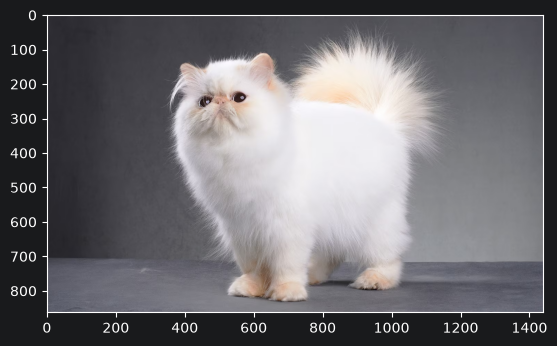

In [2]:
IMG1_PATH = p.IMAGE_ASSETS / "cat1.png"
img1 = cv2.imread(IMG1_PATH, cv2.IMREAD_COLOR_RGB)

plt.figure()
plt.imshow(img1)

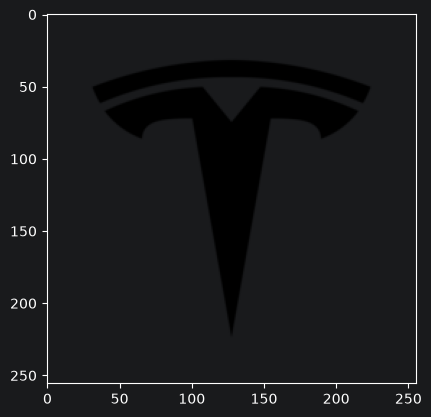

In [3]:
TESLA_LOGO_PATH = p.IMAGE_ASSETS / "tesla_logo_256.png"

tesla_logo = cv2.imread(TESLA_LOGO_PATH, cv2.IMREAD_UNCHANGED) # 4 channels

cv2.imshow("tesla_logo", tesla_logo)

plt.figure()
plt.imshow(tesla_logo, cmap="gray")



In [4]:
height, width, _ = tesla_logo.shape

SCALE_FACTOR = 1 / 4

width, height = map(lambda x: int(x * SCALE_FACTOR), [width, height])

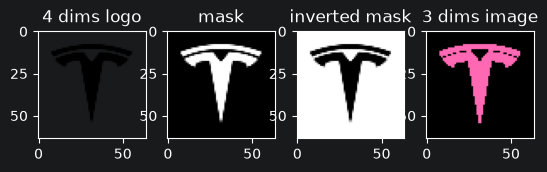

In [5]:
tesla_logo = cv2.resize(tesla_logo, (width, height), interpolation=cv2.INTER_LINEAR)

plt.figure()
plt.subplot(241)
plt.title("4 dims logo")
plt.imshow(tesla_logo, cmap="gray")

tesla_mask = tesla_logo[:, :, 3] # alpha chammel
plt.subplot(242)
plt.title("mask")
plt.imshow(tesla_mask, cmap="gray")

tesla_mask_inv = cv2.bitwise_not(tesla_mask)
plt.subplot(243)
plt.title("inverted mask")
plt.imshow(tesla_mask_inv)
plt.imshow(tesla_mask_inv, cmap="gray")

color = [255, 105, 180]
pink_bg = np.full((height, width, 3), color, np.uint8)
tesla_colored_logo = cv2.bitwise_and(pink_bg,pink_bg, mask=tesla_mask)
plt.subplot(244)
plt.title("3 dims image")
plt.imshow(tesla_colored_logo)

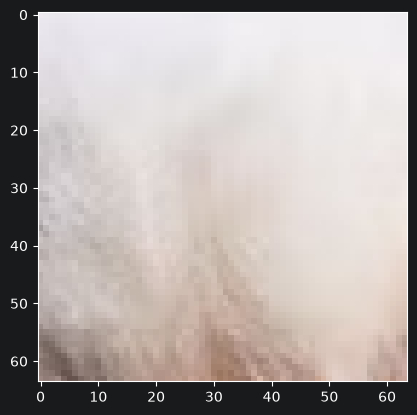

In [6]:
y0 = 168
x0 = 472

img_region = img1[y0:y0 + height, x0:x0 + width]

plt.figure()
plt.imshow(img_region)

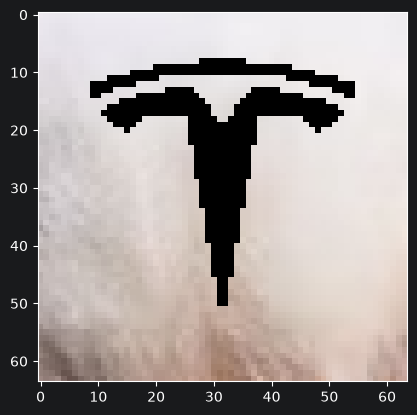

In [7]:
img_region_black = cv2.bitwise_and(img_region, img_region, mask=tesla_mask_inv)
plt.figure()
plt.imshow(img_region_black)

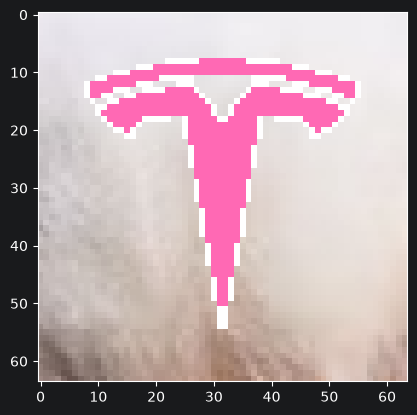

In [8]:
img_region_logo = cv2.add(img_region_black, tesla_colored_logo)
plt.figure()
plt.imshow(img_region_logo)


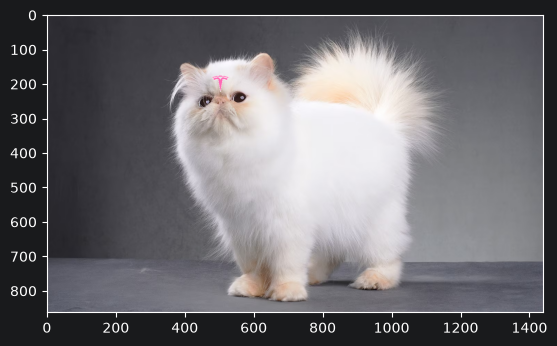

In [9]:
img1[y0:y0 + height, x0:x0 + width] = img_region_logo
plt.figure()
plt.imshow(img1)